In [1]:
# ============================================================
# 0) Imports
# ============================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
os.chdir("/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions")
# ============================================================
# 1) Configuration
# ============================================================
# Choose one:
#   DATA_MODE = "raw_pretty"   -> raw UKB pull with Showcase-style names
#   DATA_MODE = "recoded_agp"  -> ukb_as_agp_metadata.csv
DATA_MODE = "raw_pretty"

# Set your input file path here
RAW_UKB_PATH = "variable_mapping/pulled_UKBAGP.tsv"
RECODED_UKB_PATH = "variable_mapping/ukb_as_agp_metadata.csv"

# Output folder
OUT_DIR = Path("hongrui_result/alcohol_fluid_intelligence_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw UKB column names
RAW_COLS = {
    "alcohol": "Alcohol intake frequency. (FieldID: 1558)",
    "fluid": "Fluid intelligence score (FieldID: 20016)",
    "age": "Age when attended assessment centre (FieldID: 21003)",
    "sex": "Sex (FieldID: 31)",
    "race": "Ethnic background (FieldID: 21000)",
    "education": "Qualifications (FieldID: 6138)",
}

# Recoded AGP-style column names
AGP_COLS = {
    "alcohol": "alcohol_frequency",
    "fluid": "fluid_intelligence_score",
    "age": "age_corrected",
    "sex": "sex",
    "race": "race",
    "education": "highest_education",
}


In [3]:

# ============================================================
# 2) Helpers
# ============================================================
ALCOHOL_ORDER_RAW = [
    "Never",
    "Special occasions only",
    "One to three times a month",
    "Once or twice a week",
    "Three or four times a week",
    "Daily or almost daily",
]

ALCOHOL_MAP_RAW = {k: i for i, k in enumerate(ALCOHOL_ORDER_RAW)}

ALCOHOL_ORDER_RECODED = [0, 1, 2, 3, 4, 5]
ALCOHOL_LABELS_RECODED = {
    0: "Never",
    1: "Special occasions only",
    2: "1–3 times/month",
    3: "1–2 times/week",
    4: "3–4 times/week",
    5: "Daily/almost daily",
}

def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find file: {path.resolve()}")
    if path.suffix.lower() == ".tsv":
        return pd.read_csv(path, sep="\t")
    return pd.read_csv(path)

def clean_raw_ukb(df):
    cols = RAW_COLS
    out = df[[v for v in cols.values() if v in df.columns]].copy()
    out = out.rename(columns={v: k for k, v in cols.items() if v in df.columns})

    # fluid + age
    out["fluid"] = pd.to_numeric(out["fluid"], errors="coerce")
    out["age"] = pd.to_numeric(out["age"], errors="coerce")

    # standardize strings
    for c in ["alcohol", "sex", "race", "education"]:
        if c in out.columns:
            out[c] = out[c].astype("string").str.strip()

    # ordered alcohol category
    out.loc[~out["alcohol"].isin(ALCOHOL_ORDER_RAW), "alcohol"] = pd.NA
    out["alcohol_cat"] = pd.Categorical(out["alcohol"], categories=ALCOHOL_ORDER_RAW, ordered=True)
    out["alcohol_score"] = out["alcohol"].map(ALCOHOL_MAP_RAW).astype("float")

    return out

def clean_recoded_agp(df):
    cols = AGP_COLS
    out = df[[v for v in cols.values() if v in df.columns]].copy()
    out = out.rename(columns={v: k for k, v in cols.items() if v in df.columns})

    out["fluid"] = pd.to_numeric(out["fluid"], errors="coerce")
    out["age"] = pd.to_numeric(out["age"], errors="coerce")

    # recoded sex is usually 0/1 in your pipeline
    if "sex" in out.columns:
        out["sex"] = out["sex"].replace({0: "male", 1: "female"}).astype("string")

    if "alcohol" in out.columns:
        out["alcohol"] = pd.to_numeric(out["alcohol"], errors="coerce")
        out.loc[~out["alcohol"].isin(ALCOHOL_ORDER_RECODED), "alcohol"] = np.nan
        out["alcohol_score"] = out["alcohol"].astype("float")
        out["alcohol_cat"] = pd.Categorical(
            out["alcohol"].map(ALCOHOL_LABELS_RECODED),
            categories=[ALCOHOL_LABELS_RECODED[i] for i in ALCOHOL_ORDER_RECODED],
            ordered=True,
        )

    for c in ["race", "education"]:
        if c in out.columns:
            out[c] = out[c].astype("string").str.strip()

    return out

def build_main_df():
    if DATA_MODE == "raw_pretty":
        df = load_table(RAW_UKB_PATH)
        out = clean_raw_ukb(df)
    elif DATA_MODE == "recoded_agp":
        df = load_table(RECODED_UKB_PATH)
        out = clean_recoded_agp(df)
    else:
        raise ValueError("DATA_MODE must be 'raw_pretty' or 'recoded_agp'")
    return out

def summarize_missingness(df):
    return pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2)
    }).sort_values("pct_missing", ascending=False)

def fit_ols_hc3(formula, data):
    fit = smf.ols(formula, data=data).fit(cov_type="HC3")
    return fit


In [4]:

# ============================================================
# 3) Load data
# ============================================================
df = build_main_df()
print("Data shape:", df.shape)
display(df.head())

print("\nMissingness:")
display(summarize_missingness(df))

Data shape: (502244, 8)


,alcohol,fluid,age,sex,race,education,alcohol_cat,alcohol_score
0,Once or twice a week,NaN,50,Male,Indian,College or University degree,Once or twice a week,3.0
1,Once or twice a week,NaN,41,Male,British,O levels/GCSEs or equivalent,Once or twice a week,3.0
2,Once or twice a week,NaN,66,Female,British,None of the above,Once or twice a week,3.0
3,Three or four times a week,NaN,56,Male,British,NVQ or HND or HNC or equivalent,Three or four times a week,4.0
4,Special occasions only,NaN,65,Female,British,O levels/GCSEs or equivalent; A levels/AS leve...,Special occasions only,1.0



Missingness:


,n_missing,pct_missing
fluid,336878,67.07
education,4640,0.92
alcohol_cat,1502,0.30
alcohol,1502,0.30
alcohol_score,1502,0.30
race,900,0.18
sex,0,0.00
age,0,0.00


In [5]:

# ============================================================
# 4) Keep core analysis sample
# ============================================================
core_cols = ["fluid", "alcohol_cat", "alcohol_score"]
core = df[core_cols].dropna().copy()

print("Rows with both alcohol and fluid intelligence available:", len(core))
print()
display(core["alcohol_cat"].value_counts(dropna=False).sort_index())

group_summary = (
    core.groupby("alcohol_cat", observed=False)["fluid"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)
display(group_summary)

group_summary.to_csv(OUT_DIR / "alcohol_fluid_group_summary.csv", index=False)


Rows with both alcohol and fluid intelligence available: 165243



alcohol_cat
Never                         13382
Special occasions only        19895
One to three times a month    18973
Once or twice a week          41728
Three or four times a week    37231
Daily or almost daily         34034
Name: count, dtype: int64

,alcohol_cat,count,mean,std,median
0,Never,13382,5.149828,2.199296,5.0
1,Special occasions only,19895,5.380849,2.123148,5.0
2,One to three times a month,18973,5.888104,2.085681,6.0
3,Once or twice a week,41728,5.916411,2.120580,6.0
4,Three or four times a week,37231,6.315221,2.113453,6.0
5,Daily or almost daily,34034,6.418787,2.113407,6.0


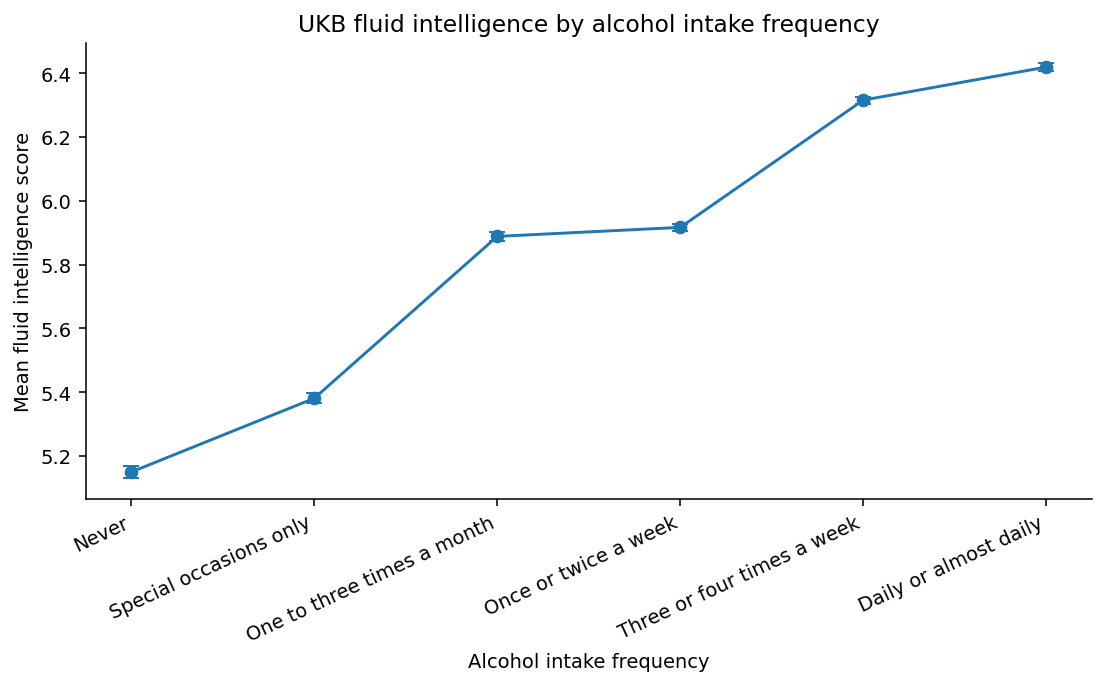

In [6]:

# ============================================================
# 5) Plot: mean fluid intelligence by alcohol category
# ============================================================
plot_df = (
    core.groupby("alcohol_cat", observed=False)["fluid"]
    .agg(["count", "mean", "std"])
    .reset_index()
)
plot_df["se"] = plot_df["std"] / np.sqrt(plot_df["count"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(plot_df["alcohol_cat"].astype(str), plot_df["mean"], yerr=plot_df["se"], fmt="o-", capsize=4)
ax.set_xlabel("Alcohol intake frequency")
ax.set_ylabel("Mean fluid intelligence score")
ax.set_title("UKB fluid intelligence by alcohol intake frequency")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

fig.savefig(OUT_DIR / "fluid_by_alcohol_frequency.png", bbox_inches="tight")
plt.show()


In [7]:

# ============================================================
# 6) Crude models
# ============================================================
# 6a) Ordered trend model
fit_trend = fit_ols_hc3("fluid ~ alcohol_score", core)
print("Crude ordered trend model: fluid ~ alcohol_score")
print(fit_trend.summary())

# 6b) Categorical model
fit_cat = fit_ols_hc3("fluid ~ C(alcohol_cat)", core)
print("\nCrude categorical model: fluid ~ C(alcohol_cat)")
print(fit_cat.summary())

with open(OUT_DIR / "model_crude_trend.txt", "w", encoding="utf-8") as f:
    f.write(fit_trend.summary().as_text())
with open(OUT_DIR / "model_crude_categorical.txt", "w", encoding="utf-8") as f:
    f.write(fit_cat.summary().as_text())


Crude ordered trend model: fluid ~ alcohol_score
                            OLS Regression Results                            
Dep. Variable:                  fluid   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     5695.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:45:26   Log-Likelihood:            -3.5880e+05
No. Observations:              165243   AIC:                         7.176e+05
Df Residuals:                  165241   BIC:                         7.176e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [8]:

# ============================================================
# 7) Build adjusted analysis dataset
# ============================================================
adj_cols = ["fluid", "alcohol_cat", "alcohol_score", "age", "sex", "race", "education"]
adj = df[[c for c in adj_cols if c in df.columns]].copy()

# Basic cleaning of common missing / special values
for c in ["sex", "race", "education"]:
    if c in adj.columns:
        adj[c] = adj[c].astype("object").replace(
            {
                "Prefer not to answer": np.nan,
                "Do not know": np.nan,
                "": np.nan,
            }
        )

# For the main adjusted model below, require alcohol + fluid + age
required = ["fluid", "alcohol_cat", "alcohol_score", "age"]
adj_main = adj.dropna(subset=[c for c in required if c in adj.columns]).copy()

print("Adjusted-analysis rows:", len(adj_main))
display(summarize_missingness(adj_main))


Adjusted-analysis rows: 165243


,n_missing,pct_missing
education,1464,0.89
race,644,0.39
fluid,0,0.00
alcohol_score,0,0.00
alcohol_cat,0,0.00
sex,0,0.00
age,0,0.00


In [9]:

# ============================================================
# 8) Adjusted models
# ============================================================
# Model 1: age only
fit_age = fit_ols_hc3("fluid ~ alcohol_score + age", adj_main)
print("Adjusted model 1: fluid ~ alcohol_score + age")
print(fit_age.summary())

# Model 2: age + sex + race
formula_2 = "fluid ~ alcohol_score + age"
if "sex" in adj_main.columns:
    formula_2 += " + C(sex)"
if "race" in adj_main.columns:
    formula_2 += " + C(race)"
fit_demo = fit_ols_hc3(formula_2, adj_main)
print("\nAdjusted model 2:", formula_2)
print(fit_demo.summary())

# Model 3: age + sex + race + education
formula_3 = formula_2
if "education" in adj_main.columns:
    formula_3 += " + C(education)"
fit_full = fit_ols_hc3(formula_3, adj_main)
print("\nAdjusted model 3:", formula_3)
print(fit_full.summary())

with open(OUT_DIR / "model_adjusted_age.txt", "w", encoding="utf-8") as f:
    f.write(fit_age.summary().as_text())
with open(OUT_DIR / "model_adjusted_demo.txt", "w", encoding="utf-8") as f:
    f.write(fit_demo.summary().as_text())
with open(OUT_DIR / "model_adjusted_full.txt", "w", encoding="utf-8") as f:
    f.write(fit_full.summary().as_text())


Adjusted model 1: fluid ~ alcohol_score + age
                            OLS Regression Results                            
Dep. Variable:                  fluid   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     3143.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:45:27   Log-Likelihood:            -3.5852e+05
No. Observations:              165243   AIC:                         7.170e+05
Df Residuals:                  165240   BIC:                         7.171e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------


In [10]:

# ============================================================
# 9) Sensitivity model: alcohol as a categorical exposure
# ============================================================
formula_cat_adj = "fluid ~ C(alcohol_cat) + age"
if "sex" in adj_main.columns:
    formula_cat_adj += " + C(sex)"
if "race" in adj_main.columns:
    formula_cat_adj += " + C(race)"
if "education" in adj_main.columns:
    formula_cat_adj += " + C(education)"

fit_cat_adj = fit_ols_hc3(formula_cat_adj, adj_main)
print("Sensitivity model:", formula_cat_adj)
print(fit_cat_adj.summary())

with open(OUT_DIR / "model_adjusted_categorical_alcohol.txt", "w", encoding="utf-8") as f:
    f.write(fit_cat_adj.summary().as_text())


Sensitivity model: fluid ~ C(alcohol_cat) + age + C(sex) + C(race) + C(education)
                            OLS Regression Results                            
Dep. Variable:                  fluid   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     483.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:45:36   Log-Likelihood:            -3.3086e+05
No. Observations:              163181   AIC:                         6.620e+05
Df Residuals:                  163046   BIC:                         6.633e+05
Df Model:                         134                                         
Covariance Type:                  HC3                                         
                                                                                                                                